# 🎓 Clustering de Alumnos por Nivel de Conocimiento
### Análisis visual con datos simulados de Google Classroom

Este notebook simula los datos que obtendrías de la API de Google Classroom y aplica clustering para agrupar alumnos según su desempeño por materia.

**Flujo:**
1. Datos simulados (o reales desde la API)
2. Preprocesamiento y normalización
3. Clustering con K-Means
4. Visualizaciones: PCA, heatmap, radar, distribuciones


In [13]:
# Instalar dependencias si no las tienes
# !pip install scikit-learn pandas numpy matplotlib seaborn plotly

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

import warnings
warnings.filterwarnings("ignore")

# Estilo general
plt.rcParams["figure.facecolor"] = "#0f0f17"
plt.rcParams["axes.facecolor"]   = "#1a1a2e"
plt.rcParams["axes.edgecolor"]   = "#444"
plt.rcParams["text.color"]       = "white"
plt.rcParams["axes.labelcolor"]  = "white"
plt.rcParams["xtick.color"]      = "#aaa"
plt.rcParams["ytick.color"]      = "#aaa"
plt.rcParams["grid.color"]       = "#333"
plt.rcParams["grid.linestyle"]   = "--"

PALETTE = ["#7c3aed", "#0ea5e9", "#10b981", "#f59e0b", "#ef4444"]
print("✅ Librerías cargadas correctamente")


✅ Librerías cargadas correctamente


## 1. Datos simulados de Classroom
En producción reemplazas `generate_fake_data()` con la respuesta real de la API.


In [14]:
np.random.seed(42)

MATERIAS = ["Matemáticas", "Programación", "Base de Datos", "Redes", "IA/ML", "Inglés", "Estadística"]
N_ALUMNOS = 60

# Perfiles reales de alumnos (mezcla de gaussianas)
# Perfil 1: excelentes en todo
p1 = np.random.multivariate_normal([90]*7, np.eye(7)*25, 12)
# Perfil 2: fuertes en STEM, débiles en idiomas
p2_mean = [85, 88, 82, 79, 84, 55, 80]
p2 = np.random.multivariate_normal(p2_mean, np.eye(7)*30, 18)
# Perfil 3: promedio general
p3 = np.random.multivariate_normal([68]*7, np.eye(7)*40, 18)
# Perfil 4: dificultades generales
p4 = np.random.multivariate_normal([50]*7, np.eye(7)*35, 12)

scores = np.vstack([p1, p2, p3, p4])
scores = np.clip(scores, 0, 100)

nombres = [
    f"Alumno_{i+1:02d}" for i in range(N_ALUMNOS)
]

df_raw = pd.DataFrame(scores, columns=MATERIAS)
df_raw.insert(0, "nombre", nombres)
df_raw = df_raw.round(1)

print(f"Dataset: {df_raw.shape[0]} alumnos × {len(MATERIAS)} materias")
df_raw.head(8)


Dataset: 60 alumnos × 7 materias


,nombre,Matemáticas,Programación,Base de Datos,Redes,IA/ML,Inglés,Estadística
0,Alumno_01,92.5,89.3,93.2,97.6,88.8,88.8,97.9
1,Alumno_02,93.8,87.7,92.7,87.7,87.7,91.2,80.4
2,Alumno_03,81.4,87.2,84.9,91.6,85.5,82.9,97.3
3,Alumno_04,88.9,90.3,82.9,87.3,90.6,84.2,91.9
4,Alumno_05,87.0,88.5,87.0,99.3,89.9,84.7,94.1
5,Alumno_06,83.9,91.0,80.2,83.4,91.0,93.7,90.9
6,Alumno_07,89.4,88.5,82.6,86.4,87.7,95.3,91.7
7,Alumno_08,81.2,91.6,88.1,86.6,93.1,95.2,94.7


## 2. Preprocesamiento

In [16]:
X = df_raw[MATERIAS].values
nombres_list = df_raw["nombre"].tolist()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Media por materia (antes de escalar):")
print(df_raw[MATERIAS].mean().round(1).to_string())
print()
print("Forma del dataset escalado:", X_scaled.shape)


Media por materia (antes de escalar):
Matemáticas      74.0
Programación     75.6
Base de Datos    72.5
Redes            72.8
IA/ML            73.0
Inglés           65.0
Estadística      72.8

Forma del dataset escalado: (60, 7)


## 3. ¿Cuántos clusters? — Método del Codo + Silhouette
Usamos ambas métricas para elegir el K óptimo.


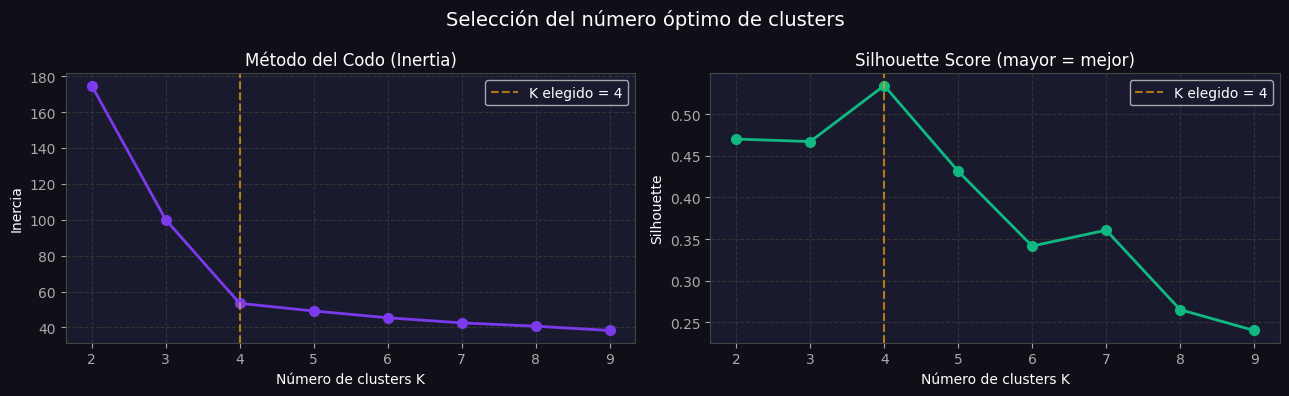

Silhouette scores: {2: 0.47, 3: 0.467, 4: 0.535, 5: 0.431, 6: 0.342, 7: 0.361, 8: 0.265, 9: 0.24}


In [4]:
inertias = []
silhouettes = []
K_range = range(2, 10)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle("Selección del número óptimo de clusters", fontsize=14, color="white")

# Elbow
axes[0].plot(list(K_range), inertias, "o-", color="#7c3aed", linewidth=2, markersize=7)
axes[0].set_title("Método del Codo (Inertia)", color="white")
axes[0].set_xlabel("Número de clusters K")
axes[0].set_ylabel("Inercia")
axes[0].axvline(x=4, color="#f59e0b", linestyle="--", alpha=0.7, label="K elegido = 4")
axes[0].legend()
axes[0].grid(True)

# Silhouette
axes[1].plot(list(K_range), silhouettes, "o-", color="#10b981", linewidth=2, markersize=7)
axes[1].set_title("Silhouette Score (mayor = mejor)", color="white")
axes[1].set_xlabel("Número de clusters K")
axes[1].set_ylabel("Silhouette")
axes[1].axvline(x=4, color="#f59e0b", linestyle="--", alpha=0.7, label="K elegido = 4")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig("elbow_silhouette.png", dpi=120, bbox_inches="tight", facecolor="#0f0f17")
plt.show()
print(f"Silhouette scores: { {k: round(s, 3) for k, s in zip(K_range, silhouettes)} }")


## 4. Aplicar K-Means con K=4

In [17]:
K = 4
kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)
labels = kmeans.fit_predict(X_scaled)

# Asignar niveles según promedio del cluster
df_result = df_raw.copy()
df_result["cluster"] = labels
df_result["promedio"] = df_result[MATERIAS].mean(axis=1).round(1)

cluster_means = df_result.groupby("cluster")["promedio"].mean().sort_values(ascending=False)
rank_map = {c: i for i, c in enumerate(cluster_means.index)}
NIVEL_NOMBRES = ["🏆 Experto", "🥈 Avanzado", "📘 Intermedio", "📗 Básico"]
df_result["nivel"] = df_result["cluster"].map(lambda c: NIVEL_NOMBRES[rank_map[c]])

print("Distribución de alumnos por nivel:")
print(df_result["nivel"].value_counts().to_string())
print()
print("Promedio general por nivel:")
print(df_result.groupby("nivel")["promedio"].mean().round(1).to_string())


Distribución de alumnos por nivel:
🥈 Avanzado      18
📘 Intermedio    18
🏆 Experto       12
📗 Básico        12

Promedio general por nivel:
nivel
🏆 Experto       89.5
📗 Básico        50.2
📘 Intermedio    68.4
🥈 Avanzado      79.3


## 5. Visualización PCA 2D — Scatter interactivo
PCA reduce las 7 dimensiones a 2 para poder graficar.


In [18]:
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(X_scaled)

df_result["pca_x"] = coords[:, 0]
df_result["pca_y"] = coords[:, 1]

varianza = pca.explained_variance_ratio_
print(f"Varianza explicada: PC1={varianza[0]:.1%}, PC2={varianza[1]:.1%}, Total={sum(varianza):.1%}")

# Hover con todas las materias
hover_cols = MATERIAS + ["promedio"]

fig = px.scatter(
    df_result,
    x="pca_x", y="pca_y",
    color="nivel",
    hover_name="nombre",
    hover_data={col: ":.1f" for col in hover_cols} | {"pca_x": False, "pca_y": False},
    title="Clusters de alumnos — Proyección PCA 2D",
    labels={"pca_x": f"PC1 ({varianza[0]:.1%})", "pca_y": f"PC2 ({varianza[1]:.1%})"},
    color_discrete_map={
        "🏆 Experto":    "#7c3aed",
        "🥈 Avanzado":   "#0ea5e9",
        "📘 Intermedio": "#10b981",
        "📗 Básico":     "#f59e0b",
    },
    template="plotly_dark",
    width=800, height=520,
    symbol="nivel",
    size_max=10,
)

# Agregar centros de clusters
centers_pca = pca.transform(kmeans.cluster_centers_)
for i, c in enumerate(centers_pca):
    nivel_name = NIVEL_NOMBRES[rank_map[i]]
    fig.add_scatter(
        x=[c[0]], y=[c[1]],
        mode="markers",
        marker=dict(size=20, symbol="x", color="white", line=dict(width=2)),
        name=f"Centro {nivel_name}",
        showlegend=False,
    )

fig.update_traces(marker=dict(size=9, opacity=0.85))
fig.update_layout(legend_title_text="Nivel")
fig.show()


Varianza explicada: PC1=81.0%, PC2=9.6%, Total=90.6%


## 6. Heatmap — Promedio por materia y nivel

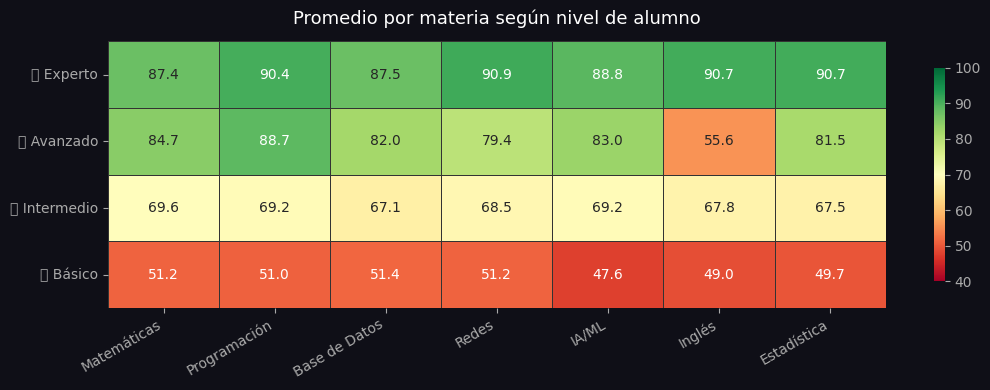

In [19]:
pivot = df_result.groupby("nivel")[MATERIAS].mean().round(1)
pivot = pivot.reindex(NIVEL_NOMBRES)

fig, ax = plt.subplots(figsize=(11, 4))
sns.heatmap(
    pivot,
    annot=True, fmt=".1f",
    cmap="RdYlGn", vmin=40, vmax=100,
    linewidths=0.5, linecolor="#333",
    ax=ax,
    cbar_kws={"shrink": 0.8},
)
ax.set_title("Promedio por materia según nivel de alumno", pad=12, fontsize=13)
ax.set_ylabel("")
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right")
plt.tight_layout()
plt.savefig("heatmap_materias.png", dpi=120, bbox_inches="tight", facecolor="#0f0f17")
plt.show()


## 7. Radar Chart — Perfil por nivel

In [8]:
pivot_radar = df_result.groupby("nivel")[MATERIAS].mean()
pivot_radar = pivot_radar.reindex(NIVEL_NOMBRES)

fig = go.Figure()

colors_radar = ["#7c3aed", "#0ea5e9", "#10b981", "#f59e0b"]

for (nivel, row), color in zip(pivot_radar.iterrows(), colors_radar):
    vals = row.tolist()
    vals_closed = vals + [vals[0]]
    cats_closed = MATERIAS + [MATERIAS[0]]
    fig.add_trace(go.Scatterpolar(
        r=vals_closed,
        theta=cats_closed,
        fill="toself",
        fillcolor=color,
        line=dict(color=color, width=2),
        opacity=0.35,
        name=nivel,
    ))

fig.update_layout(
    polar=dict(
        bgcolor="#1a1a2e",
        radialaxis=dict(visible=True, range=[30, 100], tickfont=dict(color="#888"), gridcolor="#333"),
        angularaxis=dict(tickfont=dict(color="white"), gridcolor="#444"),
    ),
    template="plotly_dark",
    title="Perfil de habilidades por nivel",
    showlegend=True,
    legend=dict(orientation="h", y=-0.15),
    width=700, height=520,
)
fig.show()


## 8. Distribución de promedios por nivel

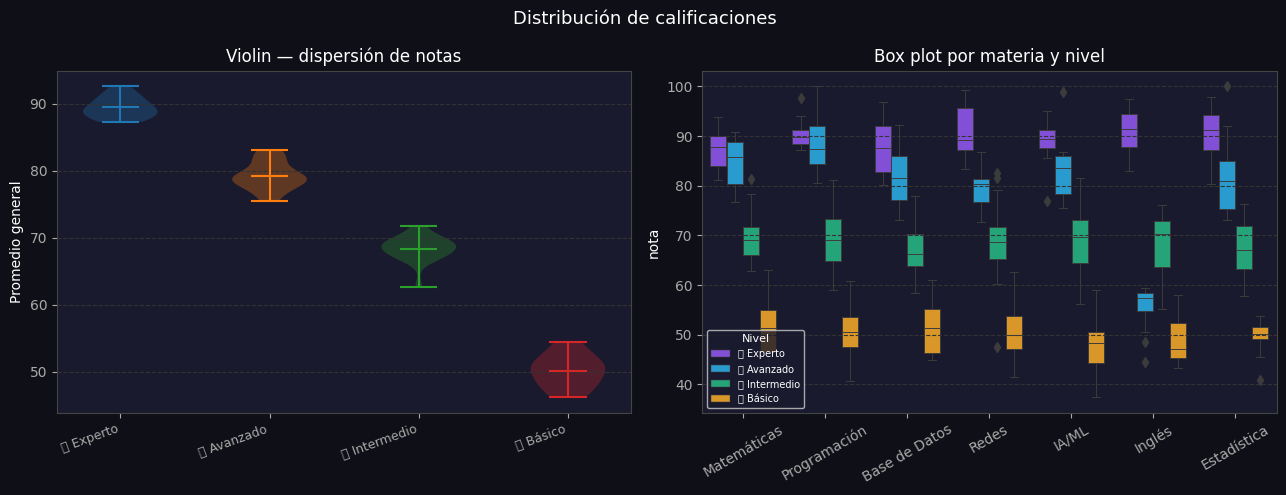

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Distribución de calificaciones", fontsize=13, color="white")

# Violin
niveles_orden = NIVEL_NOMBRES
colores = dict(zip(niveles_orden, PALETTE))

for nivel in niveles_orden:
    sub = df_result[df_result["nivel"] == nivel]["promedio"]
    axes[0].violinplot([sub], positions=[niveles_orden.index(nivel)],
                       showmeans=True, showmedians=False)

axes[0].set_xticks(range(len(niveles_orden)))
axes[0].set_xticklabels(niveles_orden, rotation=20, ha="right", fontsize=9)
axes[0].set_title("Violin — dispersión de notas")
axes[0].set_ylabel("Promedio general")
axes[0].grid(True, axis="y")

# Box plot por materia
df_melt = df_result[MATERIAS + ["nivel"]].melt(id_vars="nivel", var_name="materia", value_name="nota")
sns.boxplot(
    data=df_melt,
    x="materia", y="nota", hue="nivel",
    palette={"🏆 Experto": "#7c3aed", "🥈 Avanzado": "#0ea5e9",
             "📘 Intermedio": "#10b981", "📗 Básico": "#f59e0b"},
    ax=axes[1], linewidth=0.7,
)
axes[1].set_title("Box plot por materia y nivel")
axes[1].set_xlabel("")
axes[1].tick_params(axis="x", rotation=30)
axes[1].legend(title="Nivel", fontsize=7, title_fontsize=8)
axes[1].grid(True, axis="y")

plt.tight_layout()
plt.savefig("distribuciones.png", dpi=120, bbox_inches="tight", facecolor="#0f0f17")
plt.show()


## 9. Top alumnos por materia

In [10]:
print("=" * 55)
for materia in MATERIAS:
    top = df_result.nlargest(3, materia)[["nombre", materia, "nivel"]]
    print(f"\n🏅 Top 3 en {materia}:")
    for _, row in top.iterrows():
        print(f"   {row['nombre']:15s}  {row[materia]:5.1f}   {row['nivel']}")
print("=" * 55)



🏅 Top 3 en Matemáticas:
   Alumno_02         93.8   🏆 Experto
   Alumno_01         92.5   🏆 Experto
   Alumno_11         91.8   🏆 Experto

🏅 Top 3 en Programación:
   Alumno_17        100.0   🥈 Avanzado
   Alumno_16         98.3   🥈 Avanzado
   Alumno_11         97.7   🏆 Experto

🏅 Top 3 en Base de Datos:
   Alumno_10         96.8   🏆 Experto
   Alumno_01         93.2   🏆 Experto
   Alumno_02         92.7   🏆 Experto

🏅 Top 3 en Redes:
   Alumno_05         99.3   🏆 Experto
   Alumno_11         97.8   🏆 Experto
   Alumno_01         97.6   🏆 Experto

🏅 Top 3 en IA/ML:
   Alumno_26         98.9   🥈 Avanzado
   Alumno_10         95.0   🏆 Experto
   Alumno_08         93.1   🏆 Experto

🏅 Top 3 en Inglés:
   Alumno_12         97.4   🏆 Experto
   Alumno_07         95.3   🏆 Experto
   Alumno_08         95.2   🏆 Experto

🏅 Top 3 en Estadística:
   Alumno_30        100.0   🥈 Avanzado
   Alumno_01         97.9   🏆 Experto
   Alumno_03         97.3   🏆 Experto


## 10. Exportar resultados a CSV y JSON

In [11]:
# CSV completo
df_export = df_result[["nombre", "nivel", "promedio", "cluster"] + MATERIAS + ["pca_x", "pca_y"]]
df_export.to_csv("clusters_alumnos.csv", index=False)
print("✅ Guardado: clusters_alumnos.csv")

# JSON para la API FastAPI
import json
summary = {}
for nivel in NIVEL_NOMBRES:
    sub = df_result[df_result["nivel"] == nivel]
    summary[nivel] = {
        "total": int(len(sub)),
        "promedio_general": round(float(sub["promedio"].mean()), 2),
        "alumnos": sub["nombre"].tolist(),
        "fortalezas": sub[MATERIAS].mean().nlargest(3).index.tolist(),
    }

with open("clusters_summary.json", "w", encoding="utf-8") as f:
    json.dump(summary, f, ensure_ascii=False, indent=2)

print("✅ Guardado: clusters_summary.json")
print()
print(json.dumps(summary, ensure_ascii=False, indent=2)[:800], "...")


✅ Guardado: clusters_alumnos.csv
✅ Guardado: clusters_summary.json

{
  "🏆 Experto": {
    "total": 12,
    "promedio_general": 89.48,
    "alumnos": [
      "Alumno_01",
      "Alumno_02",
      "Alumno_03",
      "Alumno_04",
      "Alumno_05",
      "Alumno_06",
      "Alumno_07",
      "Alumno_08",
      "Alumno_09",
      "Alumno_10",
      "Alumno_11",
      "Alumno_12"
    ],
    "fortalezas": [
      "Redes",
      "Inglés",
      "Estadística"
    ]
  },
  "🥈 Avanzado": {
    "total": 18,
    "promedio_general": 79.27,
    "alumnos": [
      "Alumno_13",
      "Alumno_14",
      "Alumno_15",
      "Alumno_16",
      "Alumno_17",
      "Alumno_18",
      "Alumno_19",
      "Alumno_20",
      "Alumno_21",
      "Alumno_22",
      "Alumno_23",
      "Alumno_24",
      "Alumno_25",
      "Alumno_26",
      "Alumno_27",
      "Alumno_28",
      "Alumno ...


## 11. (Opcional) Reemplazar datos simulados con la API real

Cuando tengas el microservicio corriendo, reemplaza la celda de datos por esto:


In [12]:
# import requests

# BASE_URL = "http://localhost:8000"

# # 1. Listar cursos
# courses = requests.get(f"{BASE_URL}/courses").json()
# course_id = courses["courses"][0]["id"]
# print("Curso seleccionado:", courses["courses"][0]["name"])

# # 2. Clusterizar
# result = requests.post(f"{BASE_URL}/cluster/{course_id}", params={"n_clusters": 4}).json()

# # 3. Convertir a DataFrame
# df_raw = pd.DataFrame(result["clusters"])
# print(f"Alumnos recibidos: {result['total_students']}")
# df_raw.head()

print("⚠️  Descomenta este bloque cuando el microservicio esté corriendo en localhost:8000")


⚠️  Descomenta este bloque cuando el microservicio esté corriendo en localhost:8000
